In [15]:
import torch
import torch.nn as nn
from torch.nn.functional import gelu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
from datasets import load_dataset

imdb = load_dataset("stanfordnlp/imdb")

print(imdb)
print(imdb["train"][0])

train_data = imdb["train"]
test_data = imdb["test"]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and

In [17]:
from transformers import BertConfig, BertTokenizer, PreTrainedTokenizerBase

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
config = BertConfig(
    vocab_size=bert_tokenizer.vocab_size, hidden_size=128, num_hidden_layers=2,
    num_attention_heads=4, intermediate_size=512, max_position_embeddings=128
)

In [18]:
from typing import TypedDict
from torch.utils.data import Dataset, DataLoader
from functools import partial

class Imdb_dict(TypedDict):
    text: str
    label: int
    
class ImdbDataset(Dataset):
    def __init__(self, imdb_data: Imdb_dict):
        self.X = imdb_data["text"]
        self.y = imdb_data["label"]
        self.len: int = len(imdb_data)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self) -> int:
        return self.len

def collate_fn(batch, tokenizer:BertTokenizer, cfg:BertConfig):
    texts, labels = zip(*batch)
    encoded = tokenizer(texts, padding=True, truncation=True, 
                        max_length=cfg.max_position_embeddings, return_tensors="pt")
    
    input_ids = encoded["input_ids"] #[batch, seq_len]
    pad_mask = ~encoded["attention_mask"].bool() #[batch, seq_len]
    pad_mask = pad_mask.unsqueeze(1).unsqueeze(2)
    
    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)    
    return input_ids, labels, pad_mask

fn = partial(collate_fn, tokenizer=bert_tokenizer, cfg=config)        
train_loader = DataLoader(ImdbDataset(train_data), batch_size=32, shuffle=True, pin_memory=True, collate_fn=fn)
test_loader = DataLoader(ImdbDataset(test_data), batch_size=32, pin_memory=True, collate_fn=fn)

In [22]:
from torch import Tensor, dropout
from typing import Optional

class InhuBertEmbedding(nn.Module):
    def __init__(self, bert_config:BertConfig, dropout:float = 0.1):
        super().__init__()
        self.word_embeddings = nn.Embedding(
            bert_config.vocab_size, bert_config.hidden_size)
        self.position_embeddins = nn.Embedding(
            bert_config.max_position_embeddings, bert_config.hidden_size)
        self.layer_norm = nn.LayerNorm(bert_config.hidden_size)
        self.dropout = nn.Dropout(dropout)
    
    
    def forward(self, input_ids:Tensor):
        seq_len = input_ids.size(1)
        position_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0) #1d array -> 2d array
        
        embeddings = self.word_embeddings(input_ids) + self.position_embeddins(position_ids)
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        
        return embeddings
        
class InhuMultiheadAttention(nn.Module):
    def __init__(self, head_num:int, embed_dim:int, dropout:float=0.1):
        super().__init__()
        self.head_num = head_num
        self.embed_dim = embed_dim
        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
    
    def split_heads(self, target:Tensor) -> Tensor:
        """output dimension is [batch, head, seq, embed_dim]"""
        return target.reshape(target.size(0), target.size(1), self.head_num, self.embed_dim//self.head_num).transpose(1,2)
    
    def forward(self, query:Tensor, key:Tensor, value:Tensor, attention_mask:Optional[Tensor], pad_mask:Optional[Tensor]):
        q_split = self.split_heads(self.q(query))
        k_split = self.split_heads(self.k(key))
        v_split = self.split_heads(self.v(value))
        
        #dot product with each head''s q,k matrix, result dim is [batch, head, q, k]
        scores = q_split @ k_split.transpose(2,3) /(self.embed_dim//self.head_num) ** 0.5 

        if attention_mask is not None:
            scores.masked_fill_(attention_mask, -torch.inf)

        if pad_mask is not None:
            scores.masked_fill_(pad_mask, -torch.inf)
        
        scores = scores.softmax(dim=3)
        z = scores @ v_split
        z = z.transpose(1,2) #[batch, head, q, v] -> [batch, q, head, v]
        z = z.reshape(z.size(0), z.size(1), z.size(2) * z.size(3)) #[batch, seq, embed_dim]
        
        return (self.out(z))

class InhuBertBlock(nn.Module):
    def __init__(self, head_num:int, embed_dim:int, ff_hidden_num:int, dropout:float=0.1):
        super().__init__()
        self.attention:InhuMultiheadAttention = InhuMultiheadAttention(head_num, embed_dim, dropout)
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.ff_in = nn.Linear(embed_dim, ff_hidden_num)
        self.ff_out = nn.Linear(ff_hidden_num, embed_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, X:Tensor, attention_mask:Optional[Tensor] = None, pad_mask:Optional[Tensor] = None):
        Z = self.layer_norm1(X + self.dropout(self.attention(X, X, X, attention_mask, pad_mask))) #bottom block
        Z = self.layer_norm2(Z + self.dropout(self.ff_out(gelu(self.ff_in(Z))))) #top block
        return Z
    
class InhuBertSentimentAnal(nn.Module):
    def __init__(self, bert_config:BertConfig, dropout:float=0.1):
        super().__init__()
        self.cfg:BertConfig = bert_config
        self.embed = InhuBertEmbedding(bert_config, dropout)
        self.bert_block:nn.ModuleList = nn.ModuleList([
            InhuBertBlock(self.cfg.num_attention_heads, self.cfg.hidden_size, self.cfg.intermediate_size, dropout) 
            for _ in range(bert_config.num_hidden_layers)])
        self.output = nn.Linear(self.cfg.hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, X:Tensor, attention_mask:Optional[Tensor]=None, pad_mask:Optional[Tensor]=None):
        X_embed = self.embed(X)
        
        if attention_mask is not None:
            attention_mask = ~attention_mask
        
        Z = X_embed
        for block in self.bert_block:
            Z = block(Z, attention_mask, pad_mask)
        
        cls = Z[:, 0, :]
        logit = self.output(self.dropout(cls))
        
        return logit

In [20]:
from torch.optim import Optimizer
def train_bert_sentimentalAnal(model:InhuBertSentimentAnal, loss_fn:nn.Module, 
                               optimizer:Optimizer, train_loader:DataLoader, test_loader:DataLoader, batch:int=5):
    model.to(device)
    total_train_loss:list[float] = []
    total_test_loss:list[float] = []
    for i in range(batch):
        model.train()
        
        for X_train,y_train, pad_mask_train in train_loader:
            X_train, y_train, pad_mask_train = X_train.to(device), y_train.to(device), pad_mask_train.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_train, pad_mask=pad_mask_train)
            loss = loss_fn(y_pred, y_train)
            loss.backward()
            optimizer.step()
            total_train_loss.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            for X_test, y_test, pad_mask_test in test_loader:
                X_test, y_test, pad_mask_test = X_test.to(device), y_test.to(device), pad_mask_test.to(device)
                y_pred = model(X_test, pad_mask=pad_mask_test)
                test_loss = loss_fn(y_pred, y_test)
                total_test_loss.append(test_loss.item())
    
    return total_train_loss, total_test_loss

In [30]:
import torch.nn.functional as F

model = InhuBertSentimentAnal(bert_config=config).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

train_loss, test_loss = train_bert_sentimentalAnal(model, loss_fn, optimizer, train_loader, test_loader, batch=30)

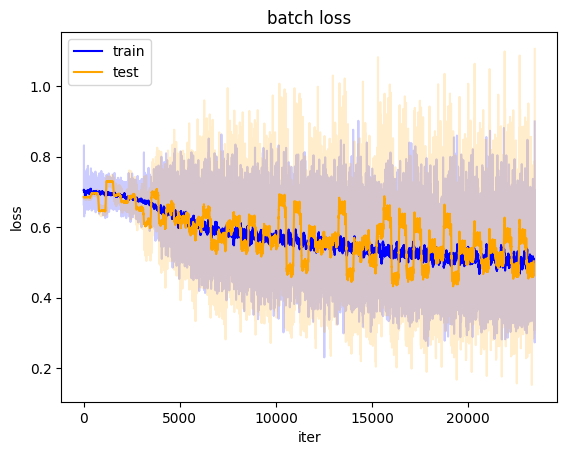

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def smooth(values, window=50):
    return np.convolve(values, np.ones(window)/window, mode='valid')


window = 50
plt.title("batch loss")
plt.plot(train_loss, alpha=0.2, color="blue")
plt.plot(test_loss, alpha=0.2, color="orange")
plt.plot(smooth(train_loss, window), label="train", color="blue")
plt.plot(smooth(test_loss, window), label="test", color="orange")
plt.legend()
plt.xlabel("iter")
plt.ylabel("loss")
plt.show()